# 04 — Signal de base dans les trajectoires de chunks (model-free)

**Question :** avant tout modèle, le contenu des chunks d'un même utilisateur
dérive-t-il de façon *structurée* dans le temps ? Autrement dit, deux chunks
voisins `(t, t+1)` sont-ils plus proches que deux chunks au hasard ?

- Si **oui** → il y a quelque chose à prédire, le JEPA a une raison d'exister.
- Si **non** (signal plat) → aucun modèle ne pourra prédire le prochain chunk,
  et les résultats d'entraînement plafonnés s'expliqueraient par l'absence de signal.

Tout ici est calculé sur le **contenu brut** (vecteur genome, genre, note,
popularité), **sans jamais toucher au checkpoint entraîné** (`jepa.pt`).

> Un chunk = `K=5` films consécutifs. Le chunk `t` couvre `items[t*K:(t+1)*K]`.
> Les vecteurs genome sont des relevances dans `[0,1]` (tout positif), donc le
> cosine brut est mécaniquement élevé : on **centre** par le genome moyen global
> avant toute similarité, pour ne garder que la structure.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.data_prep import load_all
from src import chunk_stats as cs

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

## 1. Chargement + pré-calculs (popularité, genres, centre global)

In [2]:
seq, genome, maps = load_all()
print(f"{len(seq):,} users | genome {genome.shape} | {maps.n_items:,} films")

logpop = np.log1p(cs.item_popularity(seq, maps.n_items))   # popularité (log) par item
genre_by_idx = cs.build_genre_by_idx(maps)                 # index -> genre dominant
center = cs.global_mean_chunk_genome(seq, genome, n_chunks=50000, seed=0)
print("centre global calculé (norm =", round(float((center**2).sum()**.5), 3), ")")

138,493 users | genome (10346, 1128) | 10,345 films


centre global calculé (norm = 6.129 )


## 2. Autocorrélation : similarité chunk `t` vs chunk `t+lag`

Le test central. On compare **trois** courbes/plancher :

| Série | Ce qu'elle mesure |
|---|---|
| **real** | ordre temporel réel — si ça décroît avec le lag → mémoire temporelle |
| **shuffled** | mêmes chunks, ordre mélangé dans chaque user → plancher « goût du user, sans temps » |
| **cross-user** | chunks de users différents → plancher global |

Lecture : `real(lag=1) > shuffled ≈ constante > cross-user` ⇒ signal temporel
**en plus** du signal d'identité du user.

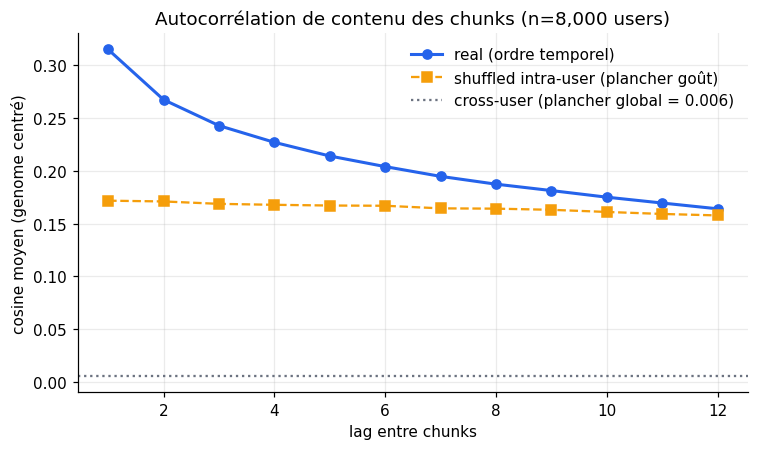

real(lag1)=0.315 | shuffled=0.172 | écart temporel = 0.143
décroissance real lag1->lag12 : 0.315 -> 0.164


In [3]:
ac = cs.autocorr_by_lag(seq, genome, max_lag=12, n_users=8000, center=center, seed=0)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(ac["lags"], ac["real"], "o-", color="#2563eb", lw=2, label="real (ordre temporel)")
ax.plot(ac["lags"], ac["shuffled"], "s--", color="#f59e0b", lw=1.5,
        label="shuffled intra-user (plancher goût)")
ax.axhline(ac["cross_user"], color="#6b7280", ls=":", lw=1.5,
           label=f"cross-user (plancher global = {ac['cross_user']:.3f})")
ax.set_xlabel("lag entre chunks"); ax.set_ylabel("cosine moyen (genome centré)")
ax.set_title(f"Autocorrélation de contenu des chunks (n={ac['n_users']:,} users)")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

gap = ac["real"][0] - ac["shuffled"][0]
print(f"real(lag1)={ac['real'][0]:.3f} | shuffled={ac['shuffled'][0]:.3f} | "
      f"écart temporel = {gap:.3f}")
print(f"décroissance real lag1->lag12 : {ac['real'][0]:.3f} -> {ac['real'][-1]:.3f}")

**Interprétation attendue.** Un écart positif `real − shuffled` au lag 1 qui
se résorbe quand le lag grandit = mémoire courte : le prochain chunk ressemble au
précédent au-delà du simple goût moyen du user. C'est le signal que le JEPA doit
capturer. Si `real` collait à `shuffled` partout, il n'y aurait **aucun** signal
temporel exploitable.

## 3. Heatmap de dérive : similarité moyenne chunk `i` × chunk `j`

Moyennée sur les users ayant au moins `P` chunks, alignée sur les `P` premiers.
- **Diagonale marquée / dégradé depuis la diagonale** → mémoire courte.
- **Blocs** → phases de goût stables puis ruptures.
- **Matrice uniforme** → pas de structure temporelle.

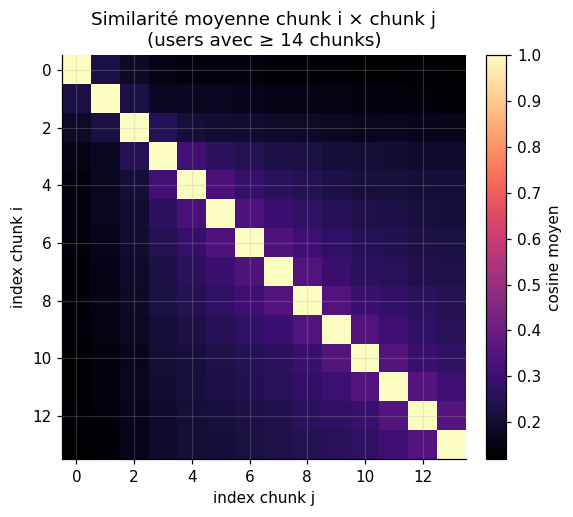

similarité vs distance sur la grille : [1.    0.316 0.268 0.243 0.228 0.214 0.202 0.19  0.18  0.168 0.155 0.139
 0.128 0.121]


In [4]:
P = 14
hm = cs.similarity_heatmap(seq, genome, P=P, n_users=8000, center=center, seed=0)

fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(hm, cmap="magma", origin="upper")
ax.set_xlabel("index chunk j"); ax.set_ylabel("index chunk i")
ax.set_title(f"Similarité moyenne chunk i × chunk j\n(users avec ≥ {P} chunks)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="cosine moyen")
plt.tight_layout(); plt.show()

# profil de décroissance depuis la diagonale (moyenne sur les diagonales à distance d)
dists = np.arange(P)
prof = [np.mean([hm[i, i+d] for i in range(P-d)]) for d in dists]
print("similarité vs distance sur la grille :", np.round(prof, 3))

## 4. Trajectoires par utilisateur (exemples)

Quelques users réels : chaque stat par chunk en fonction de l'index temporel du
chunk. On regarde à l'œil si les stats **dérivent** (tendance, ruptures) ou si
elles sont du bruit autour d'une moyenne.

- **note moyenne** : le user devient-il plus/moins sévère ?
- **popularité (log)** : mainstream → niche (ou l'inverse) ?
- **diversité intra-chunk** : chunks homogènes vs éclectiques.
- **sim. au chunk précédent** : continuité locale de contenu (cœur du signal).

In [5]:
# on prend des users avec un historique moyen (assez de chunks pour voir une tendance)
M_all = seq["items"].apply(lambda x: len(x) // cs.CHUNK_SIZE)
cand = np.where((M_all >= 18) & (M_all <= 45))[0]
rng = np.random.default_rng(3)
rows = sorted(rng.choice(cand, size=4, replace=False).tolist())
traj = cs.example_trajectories(seq, genome, logpop, genre_by_idx, user_rows=rows, center=center)
print("users choisis (row, userId, M):", [(t["user_row"], t["userId"], t["M"]) for t in traj])

users choisis (row, userId, M): [(11862, 11863, 21), (24790, 24791, 29), (32775, 32776, 24), (112370, 112371, 23)]


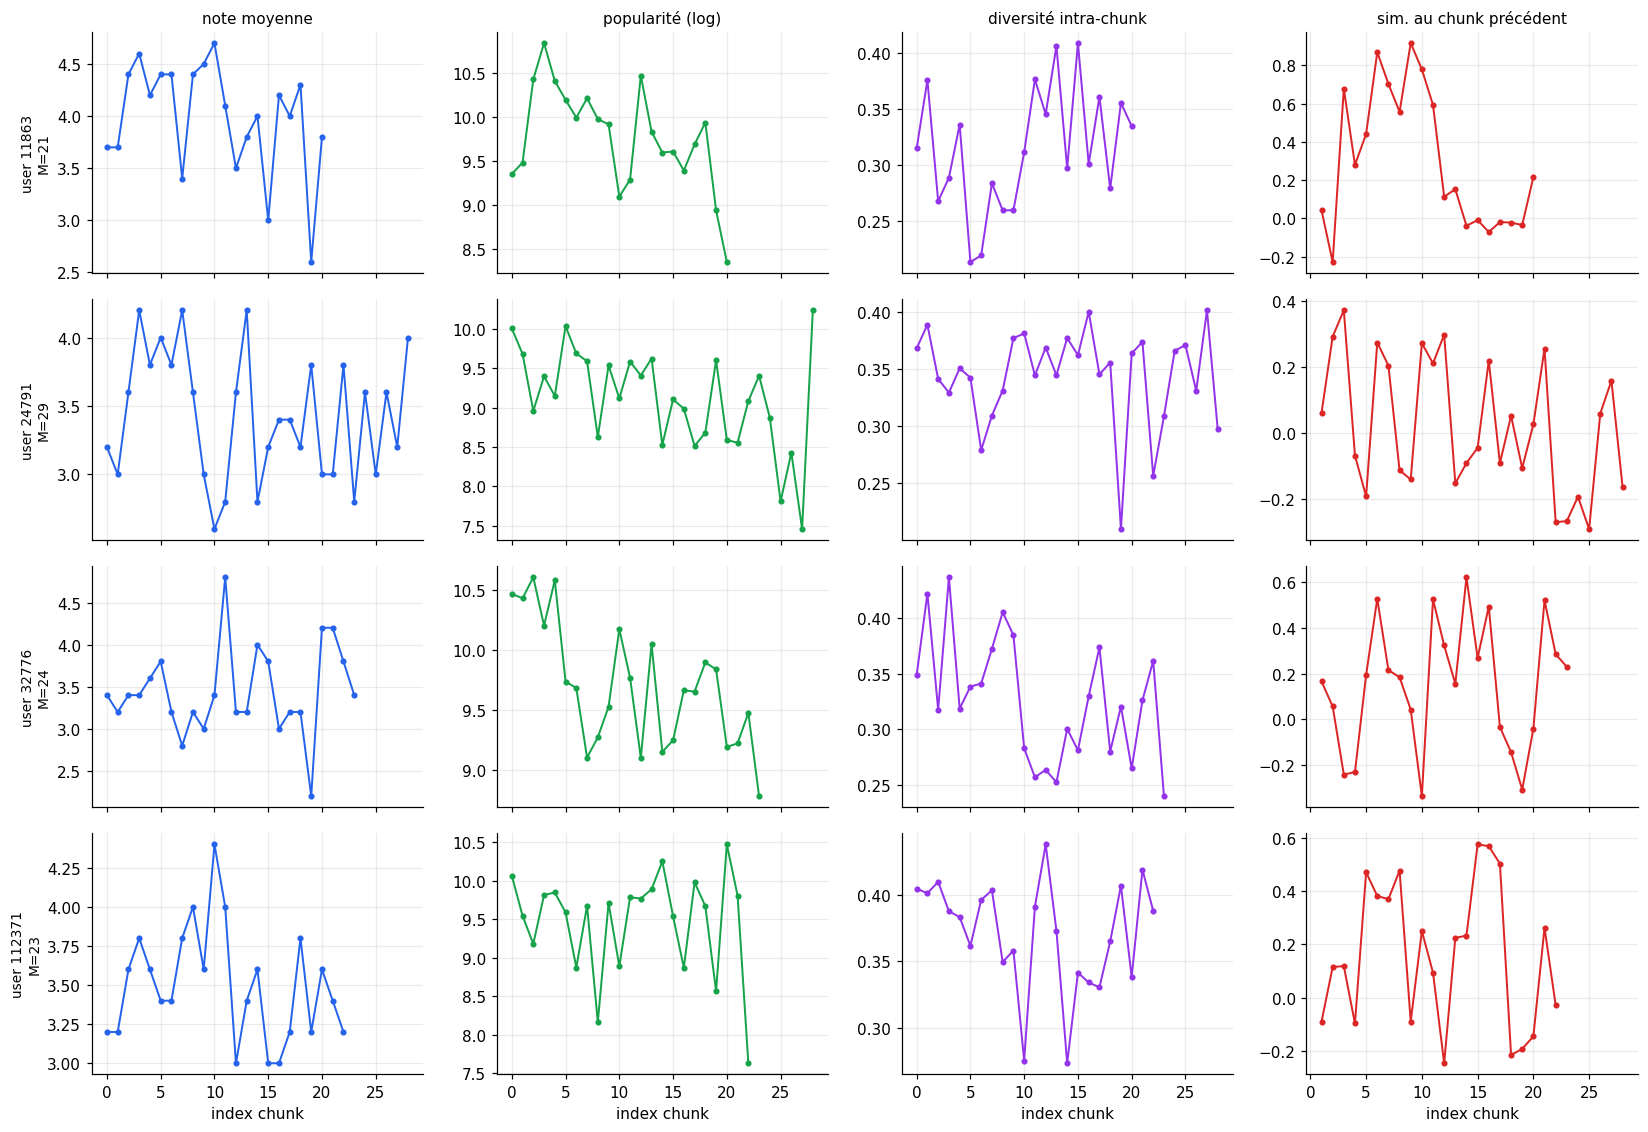

In [6]:
stats = [("rating", "note moyenne", "#2563eb"),
         ("logpop", "popularité (log)", "#16a34a"),
         ("diversity", "diversité intra-chunk", "#9333ea"),
         ("prev_sim", "sim. au chunk précédent", "#dc2626")]

fig, axes = plt.subplots(len(traj), 4, figsize=(15, 2.6 * len(traj)), sharex="col")
for r, t in enumerate(traj):
    x = np.arange(t["M"])
    for cix, (key, label, col) in enumerate(stats):
        ax = axes[r, cix]
        ax.plot(x, t[key], "o-", color=col, ms=3, lw=1.3)
        if r == 0:
            ax.set_title(label, fontsize=10)
        if cix == 0:
            ax.set_ylabel(f'user {t["userId"]}\nM={t["M"]}', fontsize=9)
        if r == len(traj) - 1:
            ax.set_xlabel("index chunk")
plt.tight_layout(); plt.show()

### Dérive de genre dominant (même users)

Le genre dominant de chaque chunk, dans l'ordre temporel : on cherche des
**plages** d'un même genre (phases) plutôt qu'une alternance purement aléatoire.

In [7]:
for t in traj:
    seqg = t["genre"]
    # compression en plages : (genre, longueur)
    runs = []
    for g in seqg:
        if runs and runs[-1][0] == g:
            runs[-1][1] += 1
        else:
            runs.append([g, 1])
    line = "  ".join(f"{g}×{n}" if n > 1 else g for g, n in runs)
    print(f"user {t['userId']:>7} (M={t['M']:2d}) : {line}")

user   11863 (M=21) : Action×8  Adventure×2  Action  Adventure  Action×3  Comedy  Adventure  Action×3  Drama
user   24791 (M=29) : Drama  Comedy  Drama  Crime  Action  Comedy  Crime×2  Action  Comedy×2  Mystery  Adventure  Action  Comedy  Action  Drama×3  Action  Drama  Comedy  Crime  Action  Crime  Comedy  Drama×2  Adventure
user   32776 (M=24) : Action×3  Animation  Action  Comedy  Drama  Comedy  Action×3  Adventure×2  Action×2  Crime  Comedy  Action  Drama  Action  Adventure  Action×2  Crime
user  112371 (M=23) : Adventure  Comedy×2  Action×3  Comedy×2  Drama  Action  Drama  Comedy×3  Action×2  Drama  Action  Drama  Action  Adventure  Comedy  Drama


## 5. Conclusion

À remplir après exécution, mais la grille de lecture est :

1. **Autocorrélation** — `real(lag1) − shuffled(lag1) > 0` et décroissance de `real`
   avec le lag ⇒ **signal temporel présent** (mémoire courte). Sinon, pas de signal.
2. **Écart shuffled ↔ cross-user** — mesure le poids de l'**identité du user**
   (goût global) : souvent le signal dominant en reco.
3. **Heatmap** — forme de la mémoire (dégradé depuis la diagonale vs blocs).
4. **Trajectoires** — les stats scalaires dérivent-elles, et les genres forment-ils
   des plages ?

**Implication pour le JEPA :** le modèle prédit le *prochain* chunk depuis tout le
passé causal. Le plafond `inv ≈ 0.98` et `pred_std < tgt_std` observés à
l'entraînement sont cohérents avec un signal temporel **réel mais faible et à
courte portée** — le prédicteur capte peu au-delà de « ressembler au chunk
récent / au goût moyen ». Ce notebook quantifie ce plafond intrinsèque, à comparer
ensuite aux baselines *répétition* et *popularité* de `src/evaluate_jepa.py`.